In [ ]:

import pandas as pd


df_train = pd.read_csv('processed_train_data.csv')
df_test = pd.read_csv('processed_test_data.csv')

# X ve y olarak ayır
X_train_final = df_train.drop('RainTomorrow', axis=1)
y_train = df_train['RainTomorrow']

X_test_final = df_test.drop('RainTomorrow', axis=1)
y_test = df_test['RainTomorrow']

print(" Veriler yüklendi")

 Veriler yüklendi


In [ ]:

try:
    
    from imblearn.over_sampling import SMOTE
except ImportError:
    pass

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier,  
                               ExtraTreesClassifier 
                              )
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, recall_score

#  SMOTE İLE VERİ DENGELEME
print(" [FİNAL] SMOTE Uygulanıyor...")
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_final, y_train)

print(f" SMOTE verisi hazır: {X_train_smote.shape}")

 [FİNAL] SMOTE Uygulanıyor...
 SMOTE verisi hazır: (176504, 60)


In [ ]:
#  GRADIENT BOOSTING & HISTOGRAM BOOSTING (TUNING + ROC) ---
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_curve, roc_auc_score
from scipy.stats import randint, uniform
import matplotlib.pyplot as plt

# 1. Hiperparametre Aralıkları
param_dist_gb = {
    'n_estimators': randint(100, 200),
    'learning_rate': uniform(0.01, 0.2),
    'max_depth': randint(3, 8)
}

param_dist_hist = {
    'max_iter': randint(100, 300),
    'learning_rate': uniform(0.01, 0.2),
    'l2_regularization': uniform(0, 1)
}

models_to_tune = [
    ("Gradient Boosting", GradientBoostingClassifier(random_state=42), param_dist_gb),
    ("HistGradientBoosting", HistGradientBoostingClassifier(random_state=42), param_dist_hist)
]

plt.figure(figsize=(8, 6))
print(" Tuning ve Eğitim Başlıyor...")

for name, model, params in models_to_tune:
    print(f"   {name} için en iyi parametreler aranıyor...", end=" ")
    
    search = RandomizedSearchCV(model, params, n_iter=5, cv=3, scoring='f1', n_jobs=-1, random_state=42)
    search.fit(X_train_smote, y_train_smote)
    
    print(f" Bulundu! \n      En İyi Parametreler: {search.best_params_}")
    
    best_model = search.best_estimator_
    y_prob = best_model.predict_proba(X_test_final)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    
   

 Tuning ve Eğitim Başlıyor...
 Bulundu! t Boosting için en iyi parametreler aranıyor... 
      En İyi Parametreler: {'learning_rate': np.float64(0.038573363584388155), 'max_depth': 5, 'n_estimators': 121}
   HistGradientBoosting için en iyi parametreler aranıyor...  Bulundu! 
      En İyi Parametreler: {'l2_regularization': np.float64(0.15599452033620265), 'learning_rate': np.float64(0.021616722433639893), 'max_iter': 187}


<Figure size 800x600 with 0 Axes>

 Scikit-Learn Boosting Modelleri Eğitiliyor...
  Gradient Boosting eğitiliyor...
  HistGradientBoosting eğitiliyor...


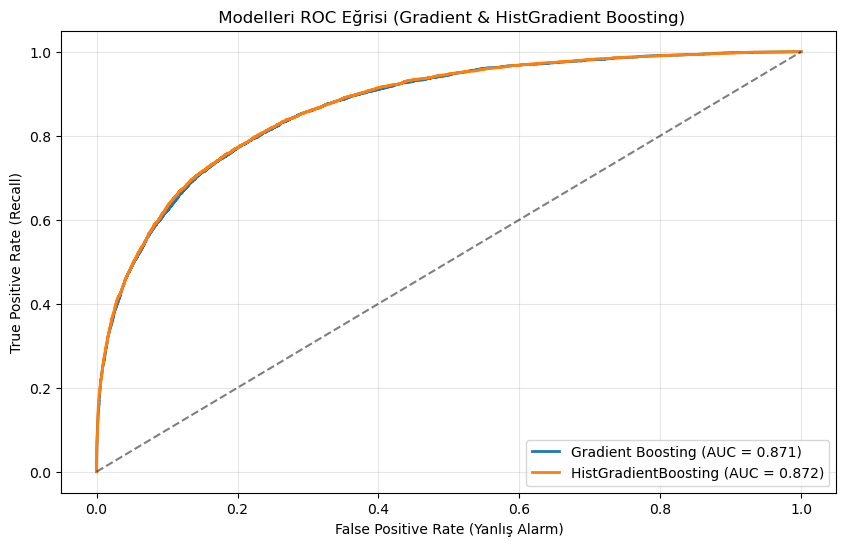


 DETAYLI PERFORMANS TABLOSU
------------------------------------------------------------


,Balanced Accuracy,Accuracy,Precision (Class 1),Recall (Class 1),F1 Score (Class 1),AUC Score
Model,,,,,,
Gradient Boosting,0.7688,0.8327,0.6204,0.6532,0.6364,0.8707
HistGradientBoosting,0.7603,0.8412,0.6557,0.6138,0.6340,0.8721


In [ ]:
# =============================================================================
# SCIKIT-LEARN BOOSTING MODELLERİ 
# =============================================================================
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, recall_score, 
                             precision_score, balanced_accuracy_score, roc_curve)
import pandas as pd
import matplotlib.pyplot as plt


member_3_models = [
    ("Gradient Boosting", GradientBoostingClassifier(
        n_estimators=121,          
        learning_rate=0.0386,      
        max_depth=5,               
        random_state=42
    )),
    ("HistGradientBoosting", HistGradientBoostingClassifier(
        max_iter=187,              
        learning_rate=0.0216,      
        l2_regularization=0.1560,  
        random_state=42
    ))
]

results = []
plt.figure(figsize=(10, 6))
print(" Scikit-Learn Boosting Modelleri Eğitiliyor...")

for name, model in member_3_models:
    print(f"  {name} eğitiliyor...")
    
    # Eğitim 
    model.fit(X_train_smote, y_train_smote)
    
    #  Tahmin 
    y_pred = model.predict(X_test_final)
    y_prob = model.predict_proba(X_test_final)[:, 1] 
    
    # C) Metriklerin Hesaplanması
    metrics = {
        "Model": name,
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (Class 1)": precision_score(y_test, y_pred),
        "Recall (Class 1)": recall_score(y_test, y_pred),
        "F1 Score (Class 1)": f1_score(y_test, y_pred),
        "AUC Score": roc_auc_score(y_test, y_prob)
    }
    results.append(metrics)
    
    # ROC Eğrisi Çizimi
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {metrics["AUC Score"]:.3f})', linewidth=2)

# Grafik Ayarları
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.title(' Modelleri ROC Eğrisi (Gradient & HistGradient Boosting)')
plt.xlabel('False Positive Rate (Yanlış Alarm)')
plt.ylabel('True Positive Rate (Recall)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

# Tabloyu Göster
df_res = pd.DataFrame(results).set_index("Model")
print("\n DETAYLI PERFORMANS TABLOSU")
print("-" * 60)
try:
    display(df_res.style.format("{:.4f}"))
except:
    print(df_res)

In [ ]:
#PyTorch Derin Ogrenme

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, recall_score, classification_report




device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Çalışma Ortamı: {device}")


X_train_pt = torch.tensor(X_train_smote.values, dtype=torch.float32).to(device)
y_train_pt = torch.tensor(y_train_smote.values, dtype=torch.float32).unsqueeze(1).to(device)
X_test_pt = torch.tensor(X_test_final.values, dtype=torch.float32).to(device)
y_test_pt = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1).to(device)


train_dataset = TensorDataset(X_train_pt, y_train_pt)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
input_dim = X_train_pt.shape[1]

# 4. EĞİTİM FONKSİYONU 
def train_and_evaluate(model, model_name, epochs=15):
    model = model.to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    print(f"  {model_name} eğitiliyor...")
    model.train()
    for epoch in range(epochs):
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
    model.eval()
    with torch.no_grad():
        y_pred_prob = model(X_test_pt).cpu().numpy()
        y_pred_class = (y_pred_prob > 0.5).astype(float)
        
    y_test_np = y_test_pt.cpu().numpy()
    
    # Metrikler
    metrics = {
        "Model": f"[DL-PyTorch] {model_name}",
        "Accuracy": accuracy_score(y_test_np, y_pred_class),
        "F1 Score (Weighted)": f1_score(y_test_np, y_pred_class, average='weighted'),
        "Recall (Weighted)": recall_score(y_test_np, y_pred_class, average='weighted'),
        "AUC Score": roc_auc_score(y_test_np, y_pred_prob)
    }
    
    # Sınıf Bazlı
    report = classification_report(y_test_np, y_pred_class, output_dict=True)
    class_metrics = [
        {"Model": f"[DL-PyTorch] {model_name}", "Class": "1 (Rain)", 
         "Precision": report['1.0']['precision'], "Recall": report['1.0']['recall'], "F1-Score": report['1.0']['f1-score']}
    ]
    return metrics, class_metrics

print("Tamamlandı")

Çalışma Ortamı: cpu
Tamamlandı


In [ ]:

class efe_LeakyANN(nn.Module):
    def __init__(self, input_dim):
        super(efe_LeakyANN, self).__init__()
        self.layer1 = nn.Linear(input_dim, 64)
        self.layer2 = nn.Linear(64, 64)
        self.out = nn.Linear(64, 1)
        self.leaky = nn.LeakyReLU(0.1)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        x = self.leaky(self.layer1(x))
        x = self.leaky(self.layer2(x))
        return self.sigmoid(self.out(x))

class efe_PyTorchLogistic(nn.Module):
    def __init__(self, input_dim):
        super(efe_PyTorchLogistic, self).__init__()
        self.linear = nn.Linear(input_dim, 1)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        return self.sigmoid(self.linear(x))


models = [(efe_LeakyANN(input_dim), "efe_LeakyANN"), (efe_PyTorchLogistic(input_dim), "efe_Logistic")]
genel, sinif = [], []

for m, n in models:
    g, s = train_and_evaluate(m, n)
    genel.append(g); sinif.extend(s)

pd.DataFrame(genel).to_csv('efe_DL_genel1.csv', index=False)
pd.DataFrame(sinif).to_csv('efe_DL_sinif1.csv', index=False)
print(" Hazır")

  efe_LeakyANN eğitiliyor...
  efe_Logistic eğitiliyor...
 Hazır
